# Lecture 10a — KNN classification with the train/test split

## A real problem this technique solves

A new patient arrives at the cardiology clinic with a complete blood-work panel — cholesterol, blood pressure, age, BMI, resting heart rate. The clinic has thousands of historical patient records, each one already labelled by the attending cardiologist with one of three risk tiers: `low_risk`, `moderate_risk`, or `high_risk` for a coronary event in the next year. Triage needs the label *today* — before any specialist sees this patient — so the clinic can decide whether to book them in this week or next month.

KNN's answer: find the five historical patients with the most similar blood-work profile, look at the risk labels the cardiologist gave them, and vote. That is the **K-Nearest Neighbours** decision in one sentence — classify a new observation by looking at the labels of the K closest **already-labelled** training observations.

Notice what makes this a *classification* problem and not a clustering problem: the three risk tiers were defined by clinical guidelines *before* a single patient was scored, and every patient in the training set already has a label that a human expert assigned. The new patient needs a prediction precisely because nobody has examined them yet. We are not discovering categories — we are *assigning a known category to a new observation*.

## Supervised learning and classification, briefly

This lecture is your first **supervised** algorithm. Lecture 09 covered unsupervised clustering (KMeans), where you did not know any labels and the algorithm invented its own groups. KNN is the other side: every training observation comes with a label, and the job is to predict the label of new ones.

**Classification** specifically is the supervised task where the target labels are **discrete, pre-defined categories** — `setosa` / `versicolor` / `virginica`, `spam` / `not spam`, `low_risk` / `moderate_risk` / `high_risk`. The category set is fixed and known in advance. Contrast this with **clustering** (lecture 09), where the algorithm *invents* its own groups from the geometry of the data, and the labels do not exist until the algorithm produces them. Two different questions, two different algorithms:

- **Classification asks:** *"Which of these known categories does this new point belong to?"*
- **Clustering asks:** *"Are there natural groupings in this data at all, and if so, how many?"*

A quick test when you are unsure which one your problem is: **do the labels exist before you fit the model?** If yes → classification. If no → clustering. (If labels are continuous numbers instead of categories, it is *regression* — covered in lecture 11 and previewed in the optional `lec_10f_knn_regression_teaser.ipynb`.)

Because this is the first lecture that does supervised prediction, it also introduces a second new concept that every supervised algorithm in the rest of the course will rely on: the **train/test split**. We hold some of the data back from the fitting step so we can measure honestly how well the model predicts on observations it has not seen. That split is the single most important habit in supervised learning, and we cover it in detail in §B1.3 below.

## Three places KNN classification still earns its keep

KNN is rarely the best-in-class production classifier in 2026 — gradient-boosted trees beat it on tabular data, neural networks beat it on images and text. But the algorithm still shows up in three specific situations where its interpretability and zero-training-cost make it the right tool:

- **Medical triage and risk stratification** — given a patient's clinical features, predict their risk tier from a pre-defined set (`low_risk` / `moderate_risk` / `high_risk`). Labels come from clinical guidelines or historical outcomes; training data is the hospital's record of past patients. KNN is rarely the production model but is the standard *interpretable* baseline — *"we placed you in high-risk because these five similar past patients were all high-risk"* is more auditable than *"the model said so"*.
- **Few-shot classification on top of pre-trained embeddings** — the modern variant. Take a pre-trained text or image embedding (Sentence-Transformers, CLIP, OpenAI embeddings), fit a KNN on a small set of labelled examples, classify new inputs. Common in support-ticket routing, content moderation, and small-scale image classification where labelled data is scarce and you need an easy-to-update classifier that does not require retraining a deep model.
- **The honest baseline before reaching for a deep model** — on any new classification problem, KNN gives you a number to beat in ten lines of code. If your fancy neural net or gradient-boosted model can't comfortably beat KNN, the problem is the data, not the model. Every working data scientist runs this check first.

## What you will be able to do after this notebook

- Explain why supervised learning needs a train/test split, and why KNN's "lazy" property does not exempt it from this discipline.
- Distinguish a two-way train/test split from a three-way train/validation/test split, and name when each is appropriate.
- Build a complete KNN pipeline: split the data, fit the model, predict on the test set, evaluate.
- Read a confusion matrix and a classification report on a held-out test set.
- Tune `n_neighbors` by comparing train-vs-test accuracy across a range of K.
- Predict the class of new, unseen observations using the trained model.

## What this lecture deliberately leaves for later

- **Why scaling matters and what fails without it** → `lec_10b_knn_assumptions_caveats.ipynb`.
- **What the decision boundary actually looks like** → `lec_10c_knn_decision_boundaries.ipynb`.
- **The other constructor parameters** (`weights`, `metric`, `p`, `algorithm`, `leaf_size`) → `lec_10d_knn_other_parameters.ipynb` (optional).
- **When to switch off KNN to another classifier** → `lec_10e_knn_vs_other_classifiers.ipynb` (optional) and lectures 11–12.
- **KNN for regression instead of classification** → `lec_10f_knn_regression_teaser.ipynb` (optional). The full regression chapter is Lecture 11.
- **Cross-validation and `GridSearchCV`** → Lecture 13. This lecture introduces the validation set conceptually but does not implement CV.
- **Using an AI assistant on this material** → `read_agents_knn_workflows.md`.

## The iris dataset (what we are working with)

We use the classic *iris* flowers dataset — 150 observations, 4 features (sepal length/width, petal length/width), 3 species (setosa, versicolor, virginica). It is small, clean, and lets you focus on the algorithm rather than data wrangling. Lecture 08 used it for EDA and lecture 09 used it for KMeans; you should already recognise the shape. The medical-triage example in the hook above is the *kind* of problem KNN was built for; iris is what we use to *learn* the mechanics.

Background reading:

- [Iris flowers (Wikipedia)](https://en.wikipedia.org/wiki/Iris_(plant))
- [Scikit-learn user guide: nearest neighbours classification](https://scikit-learn.org/stable/modules/neighbors.html#classification)
- [`KNeighborsClassifier` API reference](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

> **Lazy learning, briefly.** KNN is called a *lazy* learner because it does no real work at `fit` time — it just memorises the training data. All the cost is at `predict` time: for every new observation, scikit-learn computes its distance to every training observation and votes on the labels of the K closest. That makes KNN fast to fit and slow to query, the opposite of most algorithms you will meet later in the course. **Note**: "lazy" describes *when* the algorithm computes — not whether it needs honest evaluation. §B1.3 below explains why even a lazy algorithm needs the train/test split.


### Import necessary modules.

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import style  # used to list available plot styles a few cells below

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

RANDOM_STATE = 42  # Seed for every random operation in this notebook.


## A. Examine the data, using graphs (EDA) and statistics.

In [2]:
# seaborn loads training datasets and returns a pandas dataframe
df = sns.load_dataset('iris')

In [4]:
# seaborn loads training datasets and returns a pandas dataframe which contains X and y.
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
125,7.2,3.2,6.0,1.8,virginica
8,4.4,2.9,1.4,0.2,setosa
110,6.5,3.2,5.1,2.0,virginica
127,6.1,3.0,4.9,1.8,virginica
93,5.0,2.3,3.3,1.0,versicolor


#### A1. Basic info about the data.

In [5]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
# Descriptive stats on all the data offer no insights concerning the 3 different categories (species).
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [8]:
# Species differences are obvious with simple descriptive stats.
df.groupby("species").describe().T

species                setosa  versicolor  virginica
sepal_length count  50.000000   50.000000  50.000000
             mean    5.006000    5.936000   6.588000
             std     0.352490    0.516171   0.635880
             min     4.300000    4.900000   4.900000
             25%     4.800000    5.600000   6.225000
             50%     5.000000    5.900000   6.500000
             75%     5.200000    6.300000   6.900000
             max     5.800000    7.000000   7.900000
sepal_width  count  50.000000   50.000000  50.000000
             mean    3.428000    2.770000   2.974000
             std     0.379064    0.313798   0.322497
             min     2.300000    2.000000   2.200000
             25%     3.200000    2.525000   2.800000
             50%     3.400000    2.800000   3.000000
             75%     3.675000    3.000000   3.175000
             max     4.400000    3.400000   3.800000
petal_length count  50.000000   50.000000  50.000000
             mean    1.462000    4.260000   5.552000
             std     0.173664    0.469911   0.551895
             min     1.000000    3.000000   4.500000
             25%     1.400000    4.000000   5.100000
             50%     1.500000    4.350000   5.550000
             75%     1.575000    4.600000   5.875000
             max     1.900000    5.100000   6.900000
petal_width  count  50.000000   50.000000  50.000000
             mean    0.246000    1.326000   2.026000
             std     0.105386    0.197753   0.274650
             min     0.100000    1.000000   1.400000
             25%     0.200000    1.200000   1.800000
             50%     0.200000    1.300000   2.000000
             75%     0.300000    1.500000   2.300000
             max     0.600000    1.800000   2.500000

### Various plots for EDA

In [9]:
# sns.  # Use tab key to aget options in Jupyter lab.

In [10]:
# plt. # Use tab key to aget options in Jupyter lab.

In [11]:
# Matplotlib styles include seaborn styles currently.
style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [12]:
# Set a common style for all plots.
# style.use('seaborn-whitegrid')  # This used to work a year ago. Not anymore.
# style.use("seaborn-v0_8-dark")  # Try this if you want.
style.use("dark_background")  # I prefer this one
plt.rcParams['figure.figsize'] = (14, 8)

#### A2. Sepal scatter visualization

In [13]:
# sns.scatterplot?

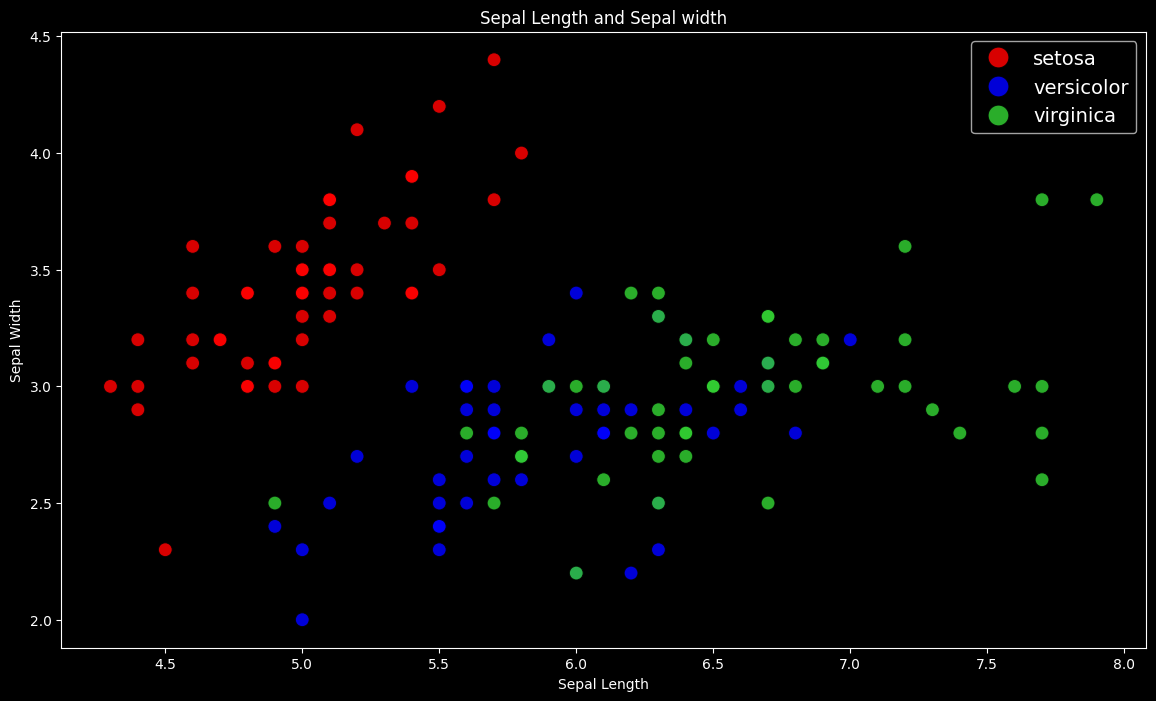

In [14]:
# Call functions with many parameters using one line for each parameter: Readability, flexibility, faster, cleaner code.
sns.scatterplot(data=df,
                x='sepal_length',
                y='sepal_width',
                hue='species',
                palette=['Red', 'Blue', 'Limegreen'],
                # palette = 'Set2', # Try this one.
                edgecolor='black',
                s=100,
                alpha=0.85  # try setting 0.5
)

plt.title('Sepal Length and Sepal width')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend(markerscale=1.5, loc="upper right", prop={'size': 14});  # Try different marker scales.

# plt.savefig("sepal.png")  # Can you guess what does this line of code do?

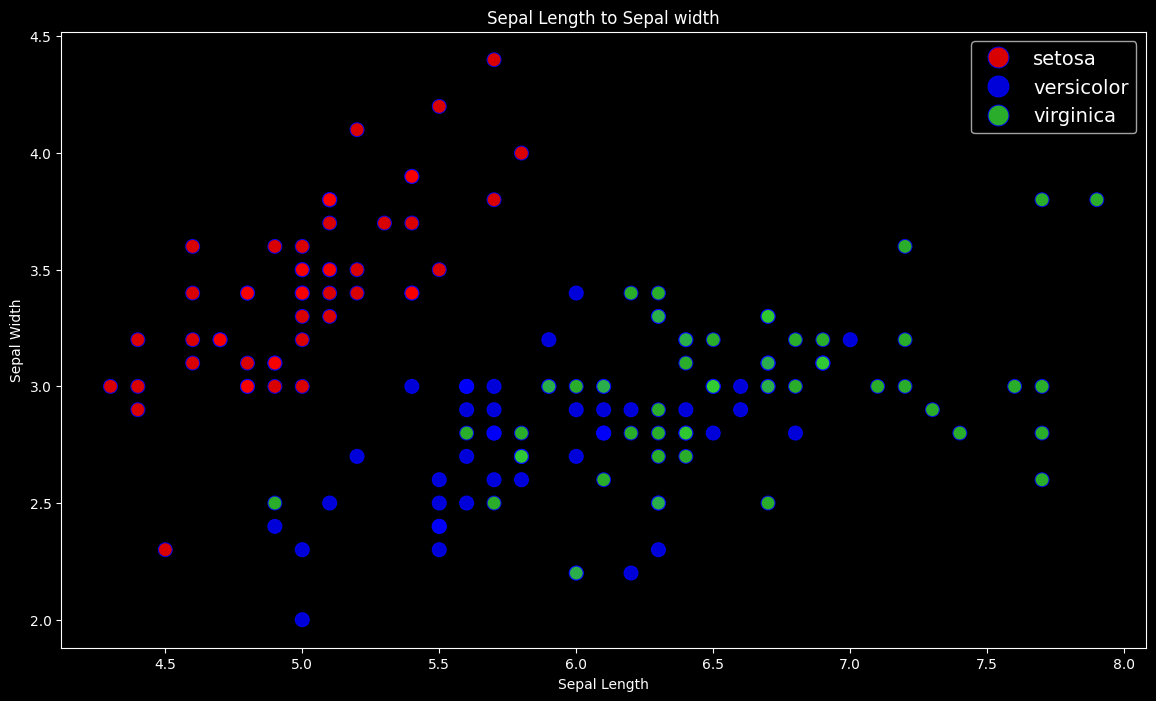

In [15]:
# Spot the three differences in the code between this plot and the one above:
# a)
# b)
# c)

# Call functions with many parameters using one line for each parameter: Readability, flexibility, faster, cleaner code.
sns.scatterplot(
    data=df,
    x='sepal_length',
    y='sepal_width',
    hue='species',
    palette=['red', 'blue', 'limegreen'],  # b)
    edgecolor='b', # c) Can you guess if this is "black" or "blue"? Explicit is better than implicit.
    s=100,
    alpha=0.85
)

plt.title('Sepal Length to Sepal width')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend(markerscale=1.5, loc="upper right", prop={'size': 14});

# plt.savefig('sepal.png')  # Can you guess what does this line of code do?

#### A3. Petal scatter visualization

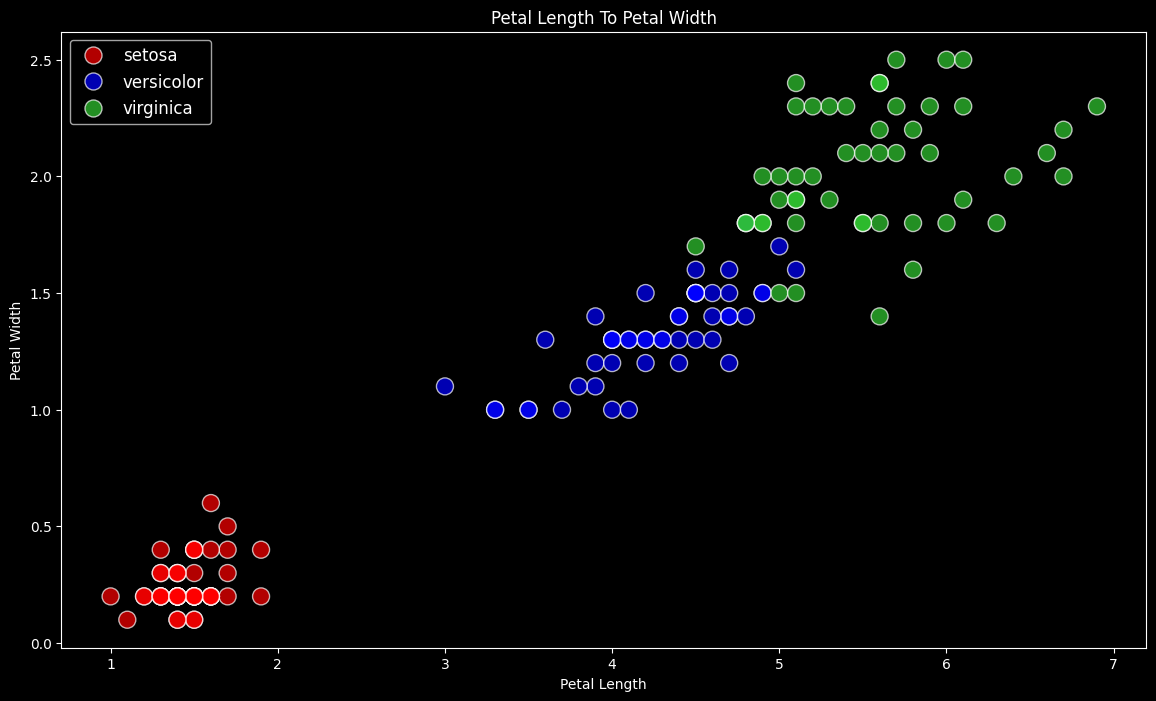

In [16]:
sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    palette = ['Red', 'Blue', 'limegreen'],
    edgecolor = 'w', s = 150, alpha = 0.7
)

plt.title('Petal Length To Petal Width')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend(loc = 'upper left', fontsize = 12);

# plt.savefig('petal.png')

In [17]:
# sns.heatmap?

#### A4. Data Heatmap

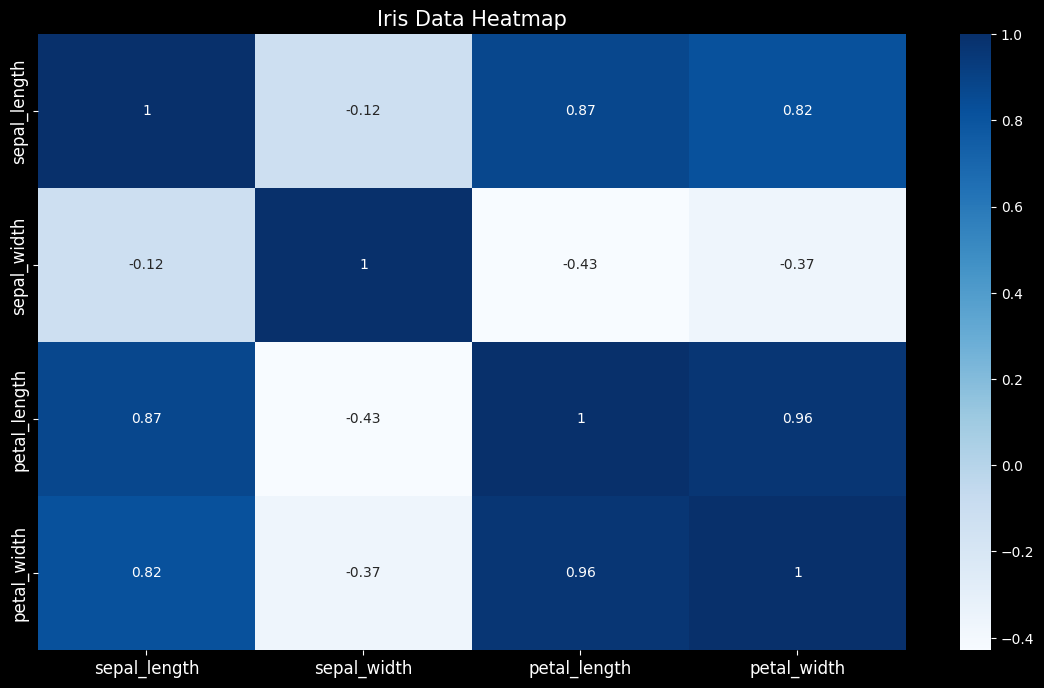

In [18]:
# df_corr = df.corr()  # This used to work until Pandas 2.0. Not anymore.

df_corr = df.corr(numeric_only=True)

sns.heatmap(
    df_corr, annot = True, 
    cmap = 'Blues',
    xticklabels = df_corr.columns.values,
    yticklabels = df_corr.columns.values
);

plt.title('Iris Data Heatmap', fontsize = 15);
plt.xticks(fontsize = 12);
plt.yticks(fontsize = 12);

# plt.savefig('heatmap.png')

#### A5. Scatter Matrix

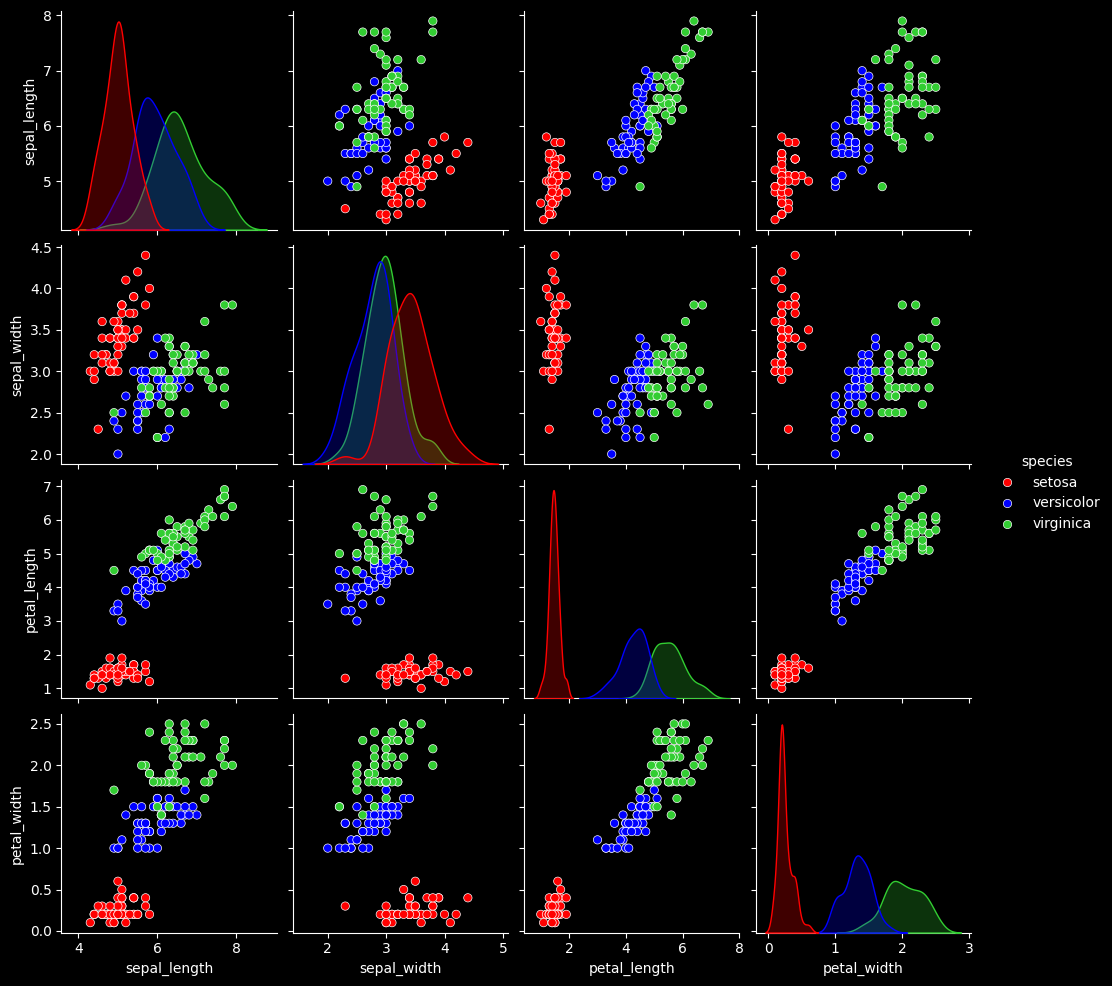

In [19]:
# all features ar numeric, so we use the data as is.
# use the species to 
sns.pairplot(data=df, hue='species', palette=['Red', 'Blue', 'limegreen']);

# plt.savefig('iris_pairplot.png')

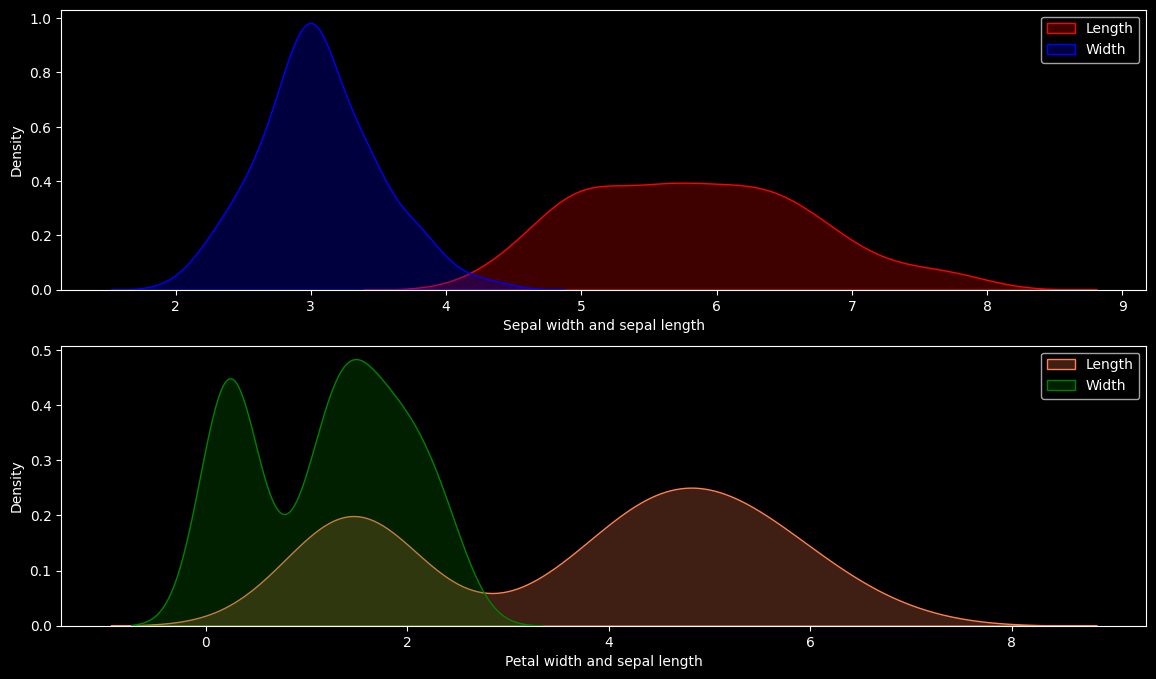

In [20]:
# 5. Distribution plot for all species of iris

ax1 = plt.subplot(211)
# sns.kdeplot(df['sepal_length'], color = 'r', shade = True)  # deprecation warning
# sns.kdeplot(df['sepal_width'], color = 'b', shade = True)
sns.kdeplot(df['sepal_length'], color = 'r', fill = True);
sns.kdeplot(df['sepal_width'], color = 'b', fill = True);
plt.xlabel('Sepal width and sepal length');
plt.legend(["Length", "Width"])


ax2 = plt.subplot(212)
# sns.kdeplot(df['petal_length'], color = 'coral', shade = True);  # deprecation warning
# sns.kdeplot(df['petal_width'], color = 'green', shade = True);
sns.kdeplot(df['petal_length'], color = 'coral', fill = True);
sns.kdeplot(df['petal_width'], color = 'green', fill = True);
plt.xlabel('Petal width and sepal length');
plt.legend(["Length", "Width"])

# plt.savefig('dist.png')

## B. Apply knn, using scikit learn

When using a function from library, a very important thing to know: the "input" data type. Also remember: libraries evolve fast.

### B1. Data Pre-processing 

#### B1.1 Separate:  
* "feature matrix" = (explanatory variables)
* "classification vector" = (target variable)

In [21]:
df.head(3)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa


In [22]:
# X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].to_numpy()
# convert to numpy array is not necessary, scikit works with pandas dataframes since ages. But that was not always the case.

X = df.iloc[:, :-1]#.to_numpy()
#X = df[["sepal_length",	"sepal_width", 	"petal_length", "petal_width"]]   # Same result as above, but what would you do if you had thousands of features?

y = df['species']#.to_numpy()

In [23]:
X.head(3)
# X[:5]  # same result, pythonic syntax

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [24]:
# 5 Random target variable values
y.sample(5)
# y[:5]

2          setosa
71     versicolor
103     virginica
25         setosa
8          setosa
Name: species, dtype: object

#### B1.2 Scale the data (if necessary)  

In this case, the features all have the same scale, all are measured in centimeters and their range is very small.
So this step is NOT necessary for this dataset.    
Below are some examples of scaling methods, for you to practice.  
Try to see if you get different results.

In [25]:
# standardization = subtract the mean and divide by s. Mean becomes zero and s = 1
# X = StandardScaler().fit_transform(X.astype(float))

# X = MaxAbsScaler().fit_transform(X.astype(float))  # feature_range=[-1, 1]

# X = MinMaxScaler().fit_transform(X.astype(float))  # feature_range=(min, max)

# X.head()

In [26]:
# Range of features values.
(X.max() - X.min())

sepal_length    3.6
sepal_width     2.4
petal_length    5.9
petal_width     2.4
dtype: float64

## B1.3 — A new concept: the train / test split

Up to this point in the course every analysis you have done used the **whole** dataset. EDA, descriptive statistics, KMeans clustering in lecture 09 — all of those used every observation, and that was fine because the work was either describing the data you had or carving it into clusters whose "correctness" only the data itself can judge.

Supervised learning is different. From this lecture forward, we are predicting a label that the algorithm did not produce. The honest question is no longer "how well does the model fit the data we trained it on?" — it is "how well does the model predict on data it has not seen?" These are not the same number, and they can be very far apart. To answer the second one we must withhold some data from the fitting step and use it only for evaluation. That is the **train/test split**, and it is the single most important habit in supervised learning.

### What the split actually does

`train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)` shuffles the rows and gives back four arrays:

- `X_train, y_train` — typically 70% of the data; passed to `fit()`.
- `X_test, y_test` — the remaining 30%; passed *only* to `predict()` and the evaluation metrics.

The model never sees `X_test` during fitting. When you score the model on `X_test`, the number is an unbiased estimate of how the model will behave on truly new data — because, as far as the model knows, `X_test` *is* new data.

The arguments that matter:

- `test_size` — what fraction goes to the test set. Common choices: 0.2, 0.25, 0.3. Smaller test sets give a noisier accuracy estimate; bigger ones leave less data for training.
- `random_state` — a seed for the shuffle. Set this to a fixed integer so re-running the notebook produces the same split. Without it, every run shuffles differently and your numbers will move around.
- `stratify=y` — keep the class proportions the same in both splits. Critical for classification: without it, you could accidentally end up with a test set that has zero virginicas, and your accuracy number would be a lie about the model's actual behaviour.

### "But KNN is lazy — does it really need this?"

Yes. The word "lazy" in lazy learning describes *when* the algorithm does work — at query time, not at fit time. It says nothing about whether evaluation needs honest data. KNN is still supervised classification, and supervised evaluation needs labels the model has not seen during fitting.

If you skip the split and score on the full dataset, three specific things go wrong:

- **K = 1 always shows 100% accuracy** on training data — every point's nearest neighbour is itself. The number is mathematically guaranteed and tells you nothing about generalisation.
- **For any K, training accuracy is systematically inflated** because each query point counts itself among its own neighbours. The bias is small for large K but never zero.
- **Tuning K becomes impossible.** The whole point of the K-sweep we are about to do in §B4 is that the *training* curve and the *test* curve diverge as K shrinks — that gap is the over-fitting signal you tune against. Without a held-out test set you only see one line on the plot and it tells you nothing useful.

An older version of this notebook fitted KNN on the full dataset throughout and reported "100% accuracy" with `weights="distance"`. That number was not an achievement — it was the model memorising every training point. We are not repeating that mistake.

### Train / test / validation: when two splits become three

There is a subtlety we will work through more deeply in Lecture 11. In real projects you usually pick hyperparameters (like `n_neighbors`, or `weights`) by trying several values and looking at how each one scores. If you keep using the same `X_test` for every attempt, you eventually pick the K that happens to do best on **that specific test set** — and your reported test accuracy is no longer unbiased. You have leaked information from the test set into your model selection.

The standard fix is the **three-way split**:

| Split | Typical size | Used for |
| --- | --- | --- |
| Training set | 60% | `fit()` — the model learns from this |
| **Validation set** | 20% | Hyperparameter selection — score every candidate K here, pick the winner |
| Test set | 20% | One final, honest evaluation of the chosen model |

The validation set is the *scratch* set: you can score on it as many times as you want during development. The test set is the *saved-for-last* set: you score on it once, at the end, and that single number is what you report to your manager (and the only number you should believe).

Schematically, the data flow looks like this:

```text
                       full labelled dataset
                              |
                  ┌───────────┴───────────┐
                  ▼                       ▼
              training (60%)        held-out (40%)
                  │                       │
                  │             ┌─────────┴─────────┐
                  ▼             ▼                   ▼
                fit()      validation (20%)     test (20%)
                  ▲             │                   │
                  │             ▼                   ▼
                  └────── score candidates ──── final eval
                           pick best K            (one number)
```

In code:

```python
# Two-way split — what we use in this lecture
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Three-way split — introduced here, deepened in lecture 11
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)
# Result: 60% train / 20% validation / 20% test
```

For *this* lecture we keep things simple and stick to the two-way split. We use the test set both to tune K (the §B4 sweep) and to report final accuracy. That is a small, controlled methodological imperfection — fine for a teaching example, not fine for production work. Lecture 11 cleans it up by formally introducing the three-way split, and Lecture 13 cleans it up *again* with `GridSearchCV` and cross-validation, which generalise the validation idea to averaging over many splits.

### When you can fit on the whole dataset

After you have selected hyperparameters and reported your test-set accuracy, it is legitimate to **refit the model on all the labelled data** before deploying it. The two-step pattern is:

1. **Model selection phase** — split, tune, evaluate. You produce a chosen K and an honest test accuracy.
2. **Production phase** — refit `KNeighborsClassifier(n_neighbors=chosen_K)` on the full labelled dataset. Use this final model for predictions on observations you have not yet measured.

Exercise 5.1 in `practice_exercises/lec_10_exercises.ipynb` does exactly this: after the K-tuning is done, it fits on all of iris and predicts on three new made-up flowers. That is correct. The split was for the *evaluation*, not for the prediction.

### The data-leakage pitfall: scale on train only

One last discipline that catches every beginner. When you scale features with `StandardScaler` (or any other transformer), the scaler must be **fit on the training set only**, then **applied** to both train and test. If you fit the scaler on the full dataset before splitting, the scaler has already "seen" the test data — your test accuracy is no longer unbiased.

```python
# WRONG — scaler sees the test set
X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, ...)

# RIGHT — scaler is fit only on training data
X_train, X_test, y_train, y_test = train_test_split(X, y, ...)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)
```

For this notebook our four iris features are all measured in centimetres with similar ranges, so we skip scaling. `lec_10b_knn_assumptions_caveats.ipynb` walks through a dataset where the scale difference is large enough to break KNN, and shows the correct fit-on-train discipline.

### Section summary

- The train/test split exists so we can evaluate supervised models honestly.
- KNN's "lazy" property describes when learning happens, not whether evaluation is needed — the split is mandatory for any honest accuracy claim.
- A two-way split is enough for this lecture; the three-way (train / validation / test) split is introduced conceptually here and deepened in Lecture 11.
- After model selection, you can refit on the full dataset for production.
- Preprocessing (scaling, encoding, imputing) is fit on training data only — leaking the transformer is a silent test-accuracy inflator.

With that grounding, here is the split for our iris data.


In [27]:
# Split into a training set and a test set.
# stratify=y keeps the proportion of each species the same in both splits.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training set: {X_train.shape[0]} observations")
print(f"Test set:     {X_test.shape[0]} observations")


Training set: 105 observations
Test set:     45 observations


### B2. Implement the scikit library

#### B2.1 Select N of neighbours and classifier model

In [ ]:
# get help in jupyter about the the KNeighborsClassifier and its parameters
KNeighborsClassifier?

Init signature:
KNeighborsClassifier(
    n_neighbors=5,
    *,
    weights='uniform',
    algorithm='auto',
    leaf_size=30,
    p=2,
    metric='minkowski',
    metric_params=None,
    n_jobs=None,
)
Docstring:     
Classifier implementing the k-nearest neighbors vote.

Read more in the :ref:`User Guide <classification>`.

Parameters
----------
n_neighbors : int, default=5
    Number of neighbors to use by default for :meth:`kneighbors` queries.

weights : {'uniform', 'distance'}, callable or None, default='uniform'
    Weight function used in prediction.  Possible values:

    - 'uniform' : uniform weights.  All points in each neighborhood
      are weighted equally.
    - 'distance' : weight points by the inverse of their distance.
      in this case, closer neighbors of a query point will have a
      greater influence than neighbors which are further away.
    - [callable] : a user-defined function which accepts an
      array of distances, and returns an array of the same shape

In [29]:
# help(KNeighborsClassifier)  # Extensive documentation.

In [30]:
k = 5  # Number of neighbours

# name that we gave to the "algo" instance
neighbours_clf = KNeighborsClassifier(n_neighbors=k)

In [31]:
neighbours_clf = KNeighborsClassifier()

#### B2.2 Fit the model to the train set (a subset of the data)

In [32]:
neighbours_clf  # Before fitting

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [33]:
neighbours_clf.fit(X_train, y_train);

In [34]:
neighbours_clf  # After fitting

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### B2.3 Create predictions on test set

In [35]:
# Predict on the held-out test set — observations the model has not seen during fit.
y_pred = neighbours_clf.predict(X_test)


In [36]:
y_pred

array(['virginica', 'versicolor', 'virginica', 'versicolor', 'virginica',
       'virginica', 'versicolor', 'versicolor', 'setosa', 'virginica',
       'setosa', 'setosa', 'virginica', 'virginica', 'setosa',
       'virginica', 'versicolor', 'setosa', 'setosa', 'setosa',
       'versicolor', 'setosa', 'versicolor', 'virginica', 'virginica',
       'versicolor', 'versicolor', 'versicolor', 'versicolor', 'setosa',
       'virginica', 'virginica', 'versicolor', 'setosa', 'virginica',
       'setosa', 'setosa', 'setosa', 'setosa', 'versicolor', 'versicolor',
       'setosa', 'versicolor', 'virginica', 'versicolor'], dtype=object)

> ⏱ **Skip if running long.** The next subsection (§B2.4) walks through single-observation prediction in pandas in fine detail (cells immediately below). The *concept* — "predict on one new row" — reappears in the K-sweep below and in Exercise 5.1. If class is running over, demo one prediction call and skim the rest of §B2.4 as at-home material.


#### B2.4 predict a single observation

In [37]:
X.head(1)  # first row

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2


In [38]:
X.iloc[0:1]  # first row, same as above different syntax

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2


In [39]:
y_pred_obs_number_one = neighbours_clf.predict(X.iloc[0:1])  # predict class of first row
y_pred_obs_number_one

array(['setosa'], dtype=object)

In [40]:
y[0:1]  # actual class value of first row

0    setosa
Name: species, dtype: object

In [41]:
# Read the warning and understand it. Data without names, still works because of training.
my_whatever_one_observation_feature_values = [[5.8, 2.8, 5.1, 2.4]]  # array of 4 random values, double brackets.
y_pred_my_whatever_values = neighbours_clf.predict(my_whatever_one_observation_feature_values)

/home/tharg/venv_projects/uoa_py_course/course_venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [42]:

y_pred_my_whatever_values = neighbours_clf.predict([[5.8, 2.8, 5.1, 2.4]])  # same as the line above.
y_pred_my_whatever_values

/home/tharg/venv_projects/uoa_py_course/course_venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['virginica'], dtype=object)

In [43]:
# Create DataFrame for the new observation to include headers
feature_names = df.columns[:-1]
feature_names

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')

In [44]:
# Create a df (values, columns headers)
one_new_observation_df = pd.DataFrame(my_whatever_one_observation_feature_values, columns=feature_names)

In [45]:
y_pred_my_whatever_values = neighbours_clf.predict(one_new_observation_df)
y_pred_my_whatever_values

array(['virginica'], dtype=object)

In [46]:
# Create predictions
y_pred_first_ten_rows = neighbours_clf.predict(X.iloc[:10])

In [47]:
# Call predictions
y_pred_first_ten_rows

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa'], dtype=object)

In [48]:
# show classifier classes
neighbours_clf.classes_

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [49]:
# Show probablilities of prediction for class for each observation
neighbours_clf.predict_proba(X)

array([[1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. , 0. ],
       [1. , 0. 

In [ ]:
# Old school python, before pandas:
# Get the predicted probabilities for sample
probabilities = neighbours_clf.predict_proba(X)

# Find the indices of samples where the maximum probability is not 1
indices = np.where(np.max(probabilities, axis=1) != 1)

# Print these samples and their corresponding probabilities
for i in indices[0]:
    print(f"Sample {i}:")
    print(X.iloc[i])
    print(f"Predicted probabilities: {probabilities[i]}")
    print("\n")

Sample 56:
sepal_length    6.3
sepal_width     3.3
petal_length    4.7
petal_width     1.6
Name: 56, dtype: float64
Predicted probabilities: [0.  0.8 0.2]


Sample 63:
sepal_length    6.1
sepal_width     2.9
petal_length    4.7
petal_width     1.4
Name: 63, dtype: float64
Predicted probabilities: [0.  0.8 0.2]


Sample 68:
sepal_length    6.2
sepal_width     2.2
petal_length    4.5
petal_width     1.5
Name: 68, dtype: float64
Predicted probabilities: [0.  0.8 0.2]


Sample 70:
sepal_length    5.9
sepal_width     3.2
petal_length    4.8
petal_width     1.8
Name: 70, dtype: float64
Predicted probabilities: [0.  0.6 0.4]


Sample 72:
sepal_length    6.3
sepal_width     2.5
petal_length    4.9
petal_width     1.5
Name: 72, dtype: float64
Predicted probabilities: [0.  0.4 0.6]


Sample 77:
sepal_length    6.7
sepal_width     3.0
petal_length    5.0
petal_width     1.7
Name: 77, dtype: float64
Predicted probabilities: [0.  0.6 0.4]


Sample 83:
sepal_length    6.0
sepal_width     2.7
petal_l

In [51]:
# Get the predicted probabilities for each sample
probabilities = neighbours_clf.predict_proba(X)

# Find the indices of samples where the maximum probability is not 1
indices = np.where(np.max(probabilities, axis=1) != 1)

# Initialize an empty DataFrame to store the results
results_df = pd.DataFrame(columns=["Sample"] + list(X.columns) + ["Predicted Probabilities"])

# Loop over the indices
for i in indices[0]:
    # Append the sample index, features and predicted probabilities to the DataFrame
    results_df.loc[len(results_df)] = [i] + list(X.iloc[i]) + [probabilities[i]]

# Print the results DataFrame
results_df

,Sample,sepal_length,sepal_width,petal_length,petal_width,Predicted Probabilities
0,56,6.3,3.3,4.7,1.6,"[0.0, 0.8, 0.2]"
1,63,6.1,2.9,4.7,1.4,"[0.0, 0.8, 0.2]"
2,68,6.2,2.2,4.5,1.5,"[0.0, 0.8, 0.2]"
3,70,5.9,3.2,4.8,1.8,"[0.0, 0.6, 0.4]"
4,72,6.3,2.5,4.9,1.5,"[0.0, 0.4, 0.6]"
5,77,6.7,3.0,5.0,1.7,"[0.0, 0.6, 0.4]"
6,83,6.0,2.7,5.1,1.6,"[0.0, 0.2, 0.8]"
7,106,4.9,2.5,4.5,1.7,"[0.0, 0.8, 0.2]"
8,119,6.0,2.2,5.0,1.5,"[0.0, 0.6, 0.4]"
9,123,6.3,2.7,4.9,1.8,"[0.0, 0.4, 0.6]"


### B3. Evaluate model performance

#### B3.1 Accuracy score

In [52]:
# Built-in score() method computes accuracy directly from (X_test, y_test).
neighbours_clf.score(X_test, y_test)


0.9777777777777777

In [53]:
# Equivalent computation via the metric function.
# y_test = true labels of the test set; y_pred = the model's predictions on the test set.
round(accuracy_score(y_test, y_pred) * 100, 4)


97.7778

In [ ]:
# Compare the first 5 actual and predicted values, side by side
y[:5], y_pred[:5]

(0    setosa
 1    setosa
 2    setosa
 3    setosa
 4    setosa
 5    setosa
 6    setosa
 7    setosa
 8    setosa
 9    setosa
 Name: species, dtype: object,
 array(['virginica', 'versicolor', 'virginica', 'versicolor', 'virginica',
        'virginica', 'versicolor', 'versicolor', 'setosa', 'virginica'],
       dtype=object))

In [55]:
# Side-by-side: true vs predicted labels on the test set.
# Reset the index of y_test so we can pair it with y_pred element-wise.
y_df = pd.DataFrame({'y_test': y_test.reset_index(drop=True), 'y_pred': y_pred})


In [56]:
# Call dateframe
y_df

,y_test,y_pred
0,virginica,virginica
1,versicolor,versicolor
2,virginica,virginica
3,versicolor,versicolor
4,virginica,virginica
5,virginica,virginica
6,versicolor,versicolor
7,versicolor,versicolor
8,setosa,setosa
9,virginica,virginica


In [57]:
# Add a boolean column: True if the model got it right on this test observation.
y_df["prediction_outcome"] = y_df.y_test == y_df.y_pred


In [58]:
y_df.head()

,y_test,y_pred,prediction_outcome
0,virginica,virginica,True
1,versicolor,versicolor,True
2,virginica,virginica,True
3,versicolor,versicolor,True
4,virginica,virginica,True


In [59]:
# Filter y_df, get rows of column prediction_outcome is False.
y_df[y_df.prediction_outcome == False]

,y_test,y_pred,prediction_outcome
42,virginica,versicolor,False


#### B3.2 Confusion Matrix

In [60]:
# Confusion matrix, manual implementation using pandas crosstab.
pd.crosstab(y_test, y_pred, rownames=['True'], colnames=['Predicted'], margins=True)


Predicted,setosa,versicolor,virginica,All
True,,,,
setosa,15,0,0,15
versicolor,0,15,0,15
virginica,0,1,14,15
All,15,16,14,45


In [61]:
confusion_matrix?

Signature:
confusion_matrix(
    y_true,
    y_pred,
    *,
    labels=None,
    sample_weight=None,
    normalize=None,
)
Docstring:
Compute confusion matrix to evaluate the accuracy of a classification.

By definition a confusion matrix :math:`C` is such that :math:`C_{i, j}`
is equal to the number of observations known to be in group :math:`i` and
predicted to be in group :math:`j`.

Thus in binary classification, the count of true negatives is
:math:`C_{0,0}`, false negatives is :math:`C_{1,0}`, true positives is
:math:`C_{1,1}` and false positives is :math:`C_{0,1}`.

Read more in the :ref:`User Guide <confusion_matrix>`.

Parameters
----------
y_true : array-like of shape (n_samples,)
    Ground truth (correct) target values.

y_pred : array-like of shape (n_samples,)
    Estimated targets as returned by a classifier.

labels : array-like of shape (n_classes,), default=None
    List of labels to index the matrix. This may be used to reorder
    or select a subset of labels.
    I

In [62]:
# Confusion matrix via scikit-learn's metric function.
confusion_matrix(y_test, y_pred, labels=["setosa", "versicolor", "virginica"])


array([[15,  0,  0],
       [ 0, 15,  0],
       [ 0,  1, 14]])

In [63]:
# Same confusion matrix, normalised so each row sums to 1.
# Rows are the true labels; columns are predictions. Use this to read per-class recall.
confusion_matrix(y_test, y_pred, normalize="true")


array([[1.        , 0.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [0.        , 0.06666667, 0.93333333]])

In [64]:
confusion_matrix(y_test, y_pred, labels=neighbours_clf.classes_)

array([[15,  0,  0],
       [ 0, 15,  0],
       [ 0,  1, 14]])

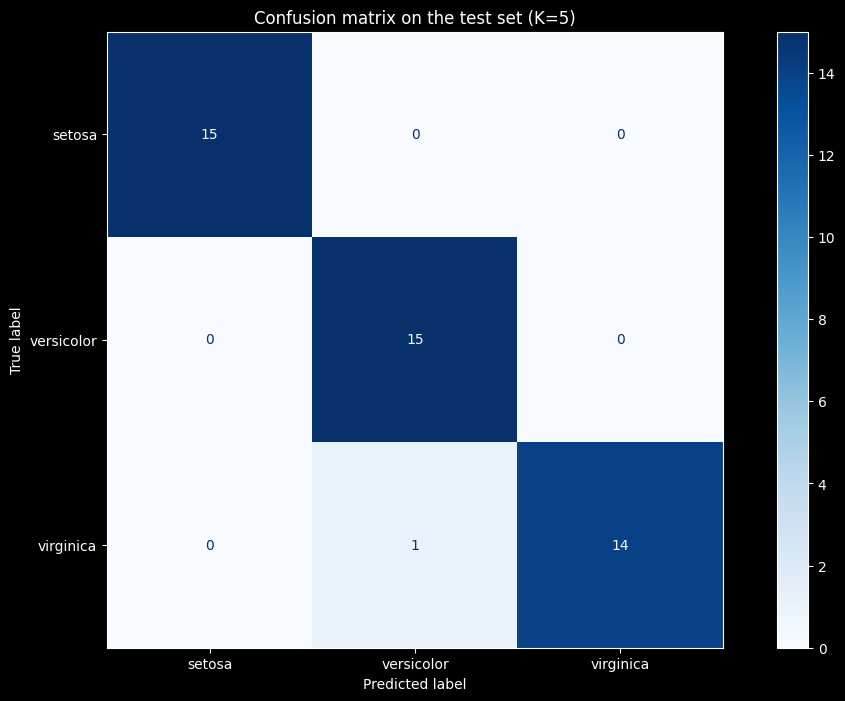

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [65]:
cm = confusion_matrix(y_test, y_pred, labels=neighbours_clf.classes_)

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=neighbours_clf.classes_)
display.plot(cmap='Blues')
plt.title(f"Confusion matrix on the test set (K={k})")
plt.show()

# Per-class precision / recall / F1 — read this together with the matrix.
print(classification_report(y_test, y_pred, target_names=neighbours_clf.classes_))


### B4. Compare different number of k for neighbors  
[simple loops](https://www.kaggle.com/jmataya/k-nearest-neighbors-classifier)

In [66]:
# Setup arrays to store BOTH the training-set accuracy and the test-set accuracy for each K.
# Comparing the two curves is how we spot under- and over-fitting.
neighbors = np.arange(1, 21)
train_accuracy = np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))


In [67]:
# Loop over different values of K.
for i, k in enumerate(neighbors):
    knn_clf = KNeighborsClassifier(n_neighbors=k)
    knn_clf.fit(X_train, y_train)

    # Score on the training set: how well the model memorised what it saw.
    train_accuracy[i] = knn_clf.score(X_train, y_train)
    # Score on the test set: how well it generalises.
    test_accuracy[i] = knn_clf.score(X_test, y_test)


In [68]:
test_accuracy  # The test-set accuracy across all K values.


array([0.93333333, 0.91111111, 0.95555556, 0.95555556, 0.97777778,
       0.93333333, 0.95555556, 0.93333333, 0.95555556, 0.95555556,
       0.93333333, 0.93333333, 0.93333333, 0.93333333, 0.95555556,
       0.95555556, 0.95555556, 0.95555556, 0.95555556, 0.93333333])

In [69]:
test_accuracy[4]  # Accuracy at K=5 (index starts at 0; neighbors[4] == 5).


np.float64(0.9777777777777777)

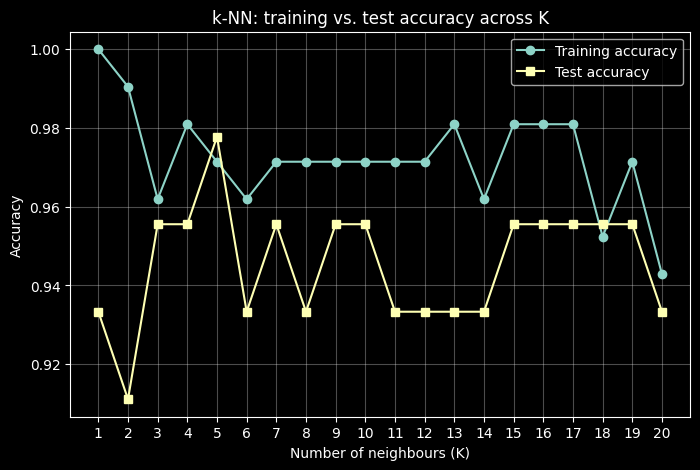

In [70]:
# Plot training accuracy and test accuracy on the same axes.
# The gap between the two lines is the over-fitting signal.
plt.figure(figsize=(8, 5))
plt.title('k-NN: training vs. test accuracy across K')
plt.plot(neighbors, train_accuracy, marker='o', label='Training accuracy')
plt.plot(neighbors, test_accuracy, marker='s', label='Test accuracy')
plt.xticks(neighbors)
plt.xlabel('Number of neighbours (K)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


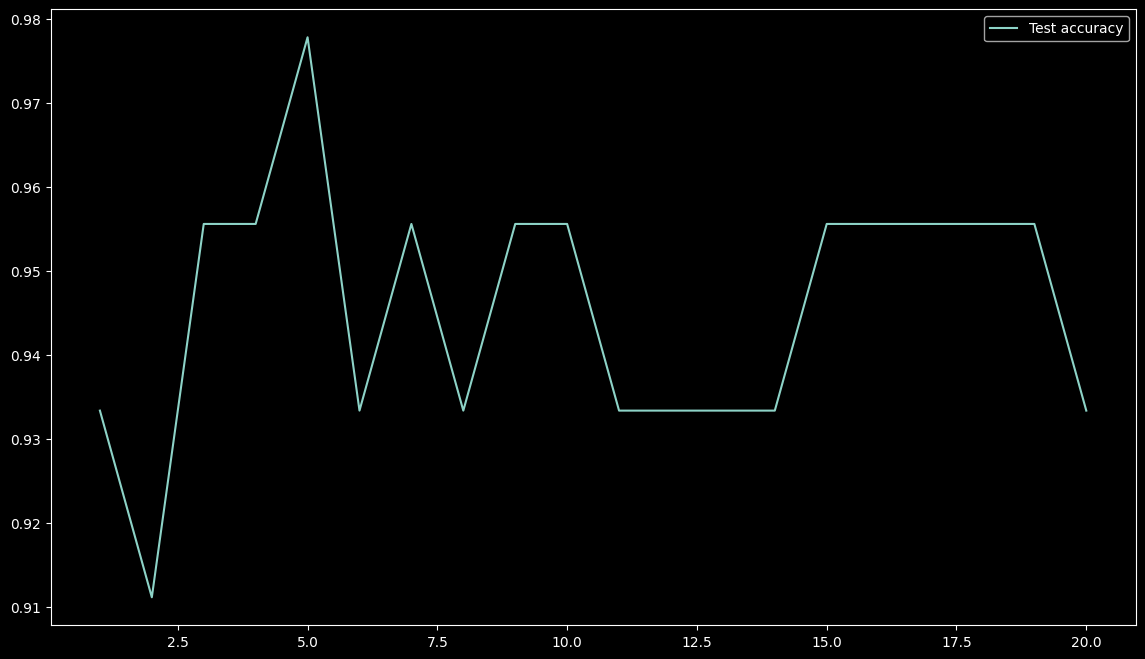

In [71]:
# Quick-and-dirty version of the plot above, with no styling — useful for prototyping.
plt.plot(neighbors, test_accuracy, label='Test accuracy')
plt.legend()
plt.show()


In [72]:
type(test_accuracy)


numpy.ndarray

In [73]:
max(test_accuracy)


np.float64(0.9777777777777777)

In [74]:
# Test accuracy for K=5 neighbours.
test_accuracy[4]


np.float64(0.9777777777777777)

In [75]:
# Apply KNN with k=15 on the training set, evaluate on the test set.
fit_neighbours_15 = KNeighborsClassifier(n_neighbors=15).fit(X_train, y_train)


In [76]:
y_pred = fit_neighbours_15.predict(X_test)

In [77]:
confusion_matrix(y_test, y_pred)

array([[15,  0,  0],
       [ 0, 14,  1],
       [ 0,  1, 14]])

In [78]:
# Pick the K that maximises TEST accuracy (not training accuracy — training accuracy will
# look better as K shrinks, simply because the model is memorising more aggressively).
best_n = 0
highest_accuracy = 0.0

for n_neighbors in range(2, 31):
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, knn.predict(X_test))

    if test_acc > highest_accuracy:
        best_n = n_neighbors
        highest_accuracy = test_acc

print(f"Best K on the test set: {best_n}")
print(f"Highest test accuracy:  {round(highest_accuracy * 100, 2)}%")


Best K on the test set: 5
Highest test accuracy:  97.78%


> ⏱ **Skip if running long.** The K=15 with `weights='distance'` demonstration in the next few cells is illustrative, not load-bearing. The visual contrast between uniform and distance weighting is covered cleanly in `lec_10c_knn_decision_boundaries.ipynb`, and the K-sweep above already shows that the maximum test accuracy is the same under both. Safe to skip in class if running long.


### Apply Knn with k=15 and use weights for distance

In [79]:
# Same K, but now weight the K nearest neighbours by distance — closer ones count more.
fit_neighbours_clf = KNeighborsClassifier(n_neighbors=15, weights='distance').fit(X_train, y_train)


In [80]:
y_pred = fit_neighbours_clf.predict(X_test)

In [81]:
confusion_matrix(y_test, y_pred)

array([[15,  0,  0],
       [ 0, 15,  0],
       [ 0,  1, 14]])

#### Distance-weighted KNN — small lift on the right datasets

When the decision boundary is irregular, weighting nearer neighbours more heavily can lift test accuracy by a couple of percent. It is not a universal upgrade — see `lec_10c_knn_decision_boundaries.ipynb` for the visual contrast between `weights="uniform"` and `weights="distance"`, and `lec_10d_knn_other_parameters.ipynb` (optional) for the other constructor parameters.


## C. Discuss optimal k in general and in case of a "tie".   


Tie-breaking rules:
even or odd k,  
number of classes,
distribution of classes, SOS
size of dataset,  
random class assignment,  
total distance weights (inverse distance)  
different distance metrics,   
loop over different k,  
k-Fold validation of data.

[Scikit learn Knn iris example](https://scikit-learn.org/stable/auto_examples/neighbors/plot_classification.html#sphx-glr-auto-examples-neighbors-plot-classification-py)

## Honest limitations of KNN

Before you ship a KNN-based system, four failure modes are worth knowing — `lec_10b_knn_assumptions_caveats.ipynb` walks through each one with a worked counter-example:

- **Feature scales.** KNN measures distance, so a feature with a 100× larger range dominates the calculation. You almost always want `StandardScaler` before fitting.
- **Curse of dimensionality.** In high-dimensional spaces all points are roughly equidistant, so "nearest" stops being meaningful. KNN tends to degrade above ~20–50 features on small datasets.
- **Class imbalance.** If 95% of your training data is class A, the K nearest neighbours of a new point are almost always class A — KNN's vote silently collapses to the majority.
- **Prediction-time memory and latency.** KNN stores the whole training set and computes distances to it at query time. Fast for hundreds of points, slow for millions.


## Where KNN earns its keep on the job

The three industry uses from the top of this notebook are not historical curiosities — they are roles KNN still plays today, often unobtrusively:

- **As the baseline.** The first model you fit on a new classification task. If the fancy model can't beat it, the problem is the data, not the model.
- **As the retrieval engine.** Every time someone runs a semantic search or a "find similar" query against an embedding store (FAISS / Annoy / pgvector / Pinecone), they are doing KNN underneath — same vote-by-neighbours, different index. The course will revisit this when you build retrieval-augmented systems.
- **As the prototype.** When you need to demonstrate that a labelled-data problem is tractable at all, before investing in a deeper model, a 10-line KNN settles the question. The trained scikit-learn object is also a clean target for the Gradio + Hugging Face deployment pattern you learned in lecture 09.

For the supervised algorithms that beat KNN under different conditions — logistic regression, decision trees, SVM — see `lec_10e_knn_vs_other_classifiers.ipynb` (optional) and lectures 11–12. For the AI-fluency thread on using assistants for the work in this notebook, see `read_agents_knn_workflows.md`.
